----

-----

# Transportation Project

## Análisis exploratorio de datos

### Cargar librerías

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar datos

In [3]:
trips_amounts = pd.read_csv('data/project_sql_result_01.csv')
neighborhoods_trips = pd.read_csv('data/project_sql_result_04.csv')

In [3]:
print(trips_amounts.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [4]:
print(trips_amounts.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [5]:
print(neighborhoods_trips.head())

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [6]:
print(neighborhoods_trips.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


Ya revisé los datasets y tienen los tipos de datos correctos según lo que se espera en cada columna y no hay datos faltantes.

In [7]:
print('Principales 10 barrios según promedio de viajes con terminación allí:')
print(neighborhoods_trips.sort_values(by = 'average_trips', ascending = False)[:10])

Principales 10 barrios según promedio de viajes con terminación allí:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


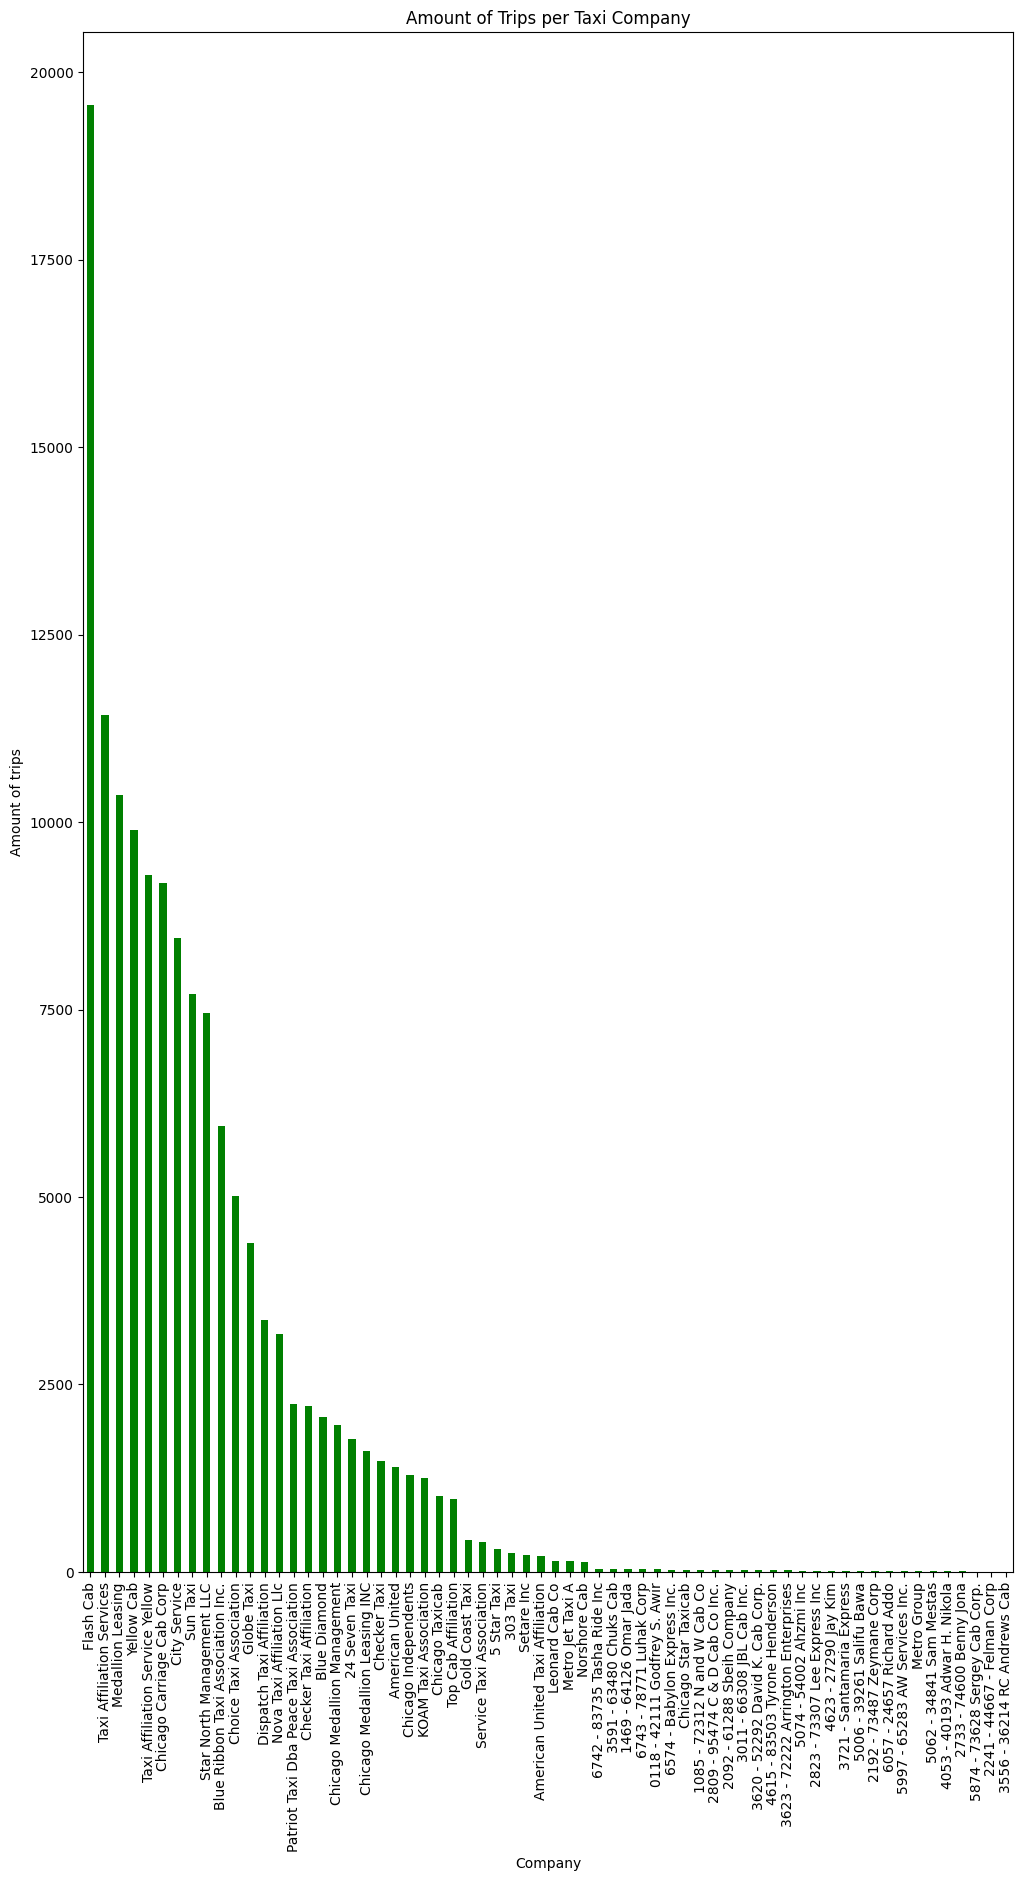

In [8]:
trips_amounts.sort_values(by = 'trips_amount', ascending = False).plot(x = 'company_name', y = 'trips_amount',kind = 'bar',
                                                                                  legend = False, title = 'Amount of Trips per Taxi Company',
                                                                                  ylabel = 'Amount of trips', xlabel = 'Company', color = 'green',
                                                                      figsize = (12,20))
plt.show()


In [9]:

print('Proporción de los viajes totales de las 13 compañías más frecuentes:')
print((sum(trips_amounts.sort_values(by = 'trips_amount', ascending = False)['trips_amount'][:13]) / sum(trips_amounts['trips_amount'])) * 100, ' %')


Proporción de los viajes totales de las 13 compañías más frecuentes:
81.58486938409887  %


Como se observa en el gráfico anterior, hay claramente compañías que tienen la hegemonía del mercado, teniendo la mayor proporción de viajes. Como se observa en el calculo anterior las 13 principales compañias de taxis (~ 20 % de ellas) con más viajes significan más del 80 % de viajes totales; tomando en cuenta que son en total 64 compañías es una desproporción inmensa, básicamente respetando el principio de Pareto, el 20 % contiene el 80 % del mercado/riqueza, haciendo así difícil obtner una buena tajada del mercado a las restantes compañías. 

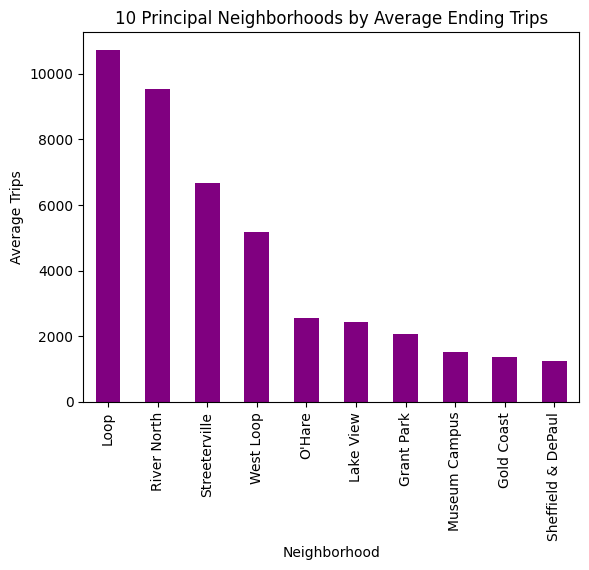

In [10]:

neighborhoods_trips.sort_values(by = 'average_trips', ascending = False)[:10].plot(x = 'dropoff_location_name', y = 'average_trips',kind = 'bar',
                                                                                  legend = False, title = '10 Principal Neighborhoods by Average Ending Trips',
                                                                                  ylabel = 'Average Trips', xlabel = 'Neighborhood', color = 'purple')
plt.show()


In [11]:
print('Proporción de los viajes totales de los 19 barrios más frecuentes:')
print((sum(neighborhoods_trips.sort_values(by = 'average_trips', ascending = False)['average_trips'][:19]) / sum(neighborhoods_trips['average_trips'])) * 100, ' %')


Proporción de los viajes totales de los 19 barrios más frecuentes:
89.94860347443796  %


Al igual que con el gráfico anterior, aquí el 20% de barrios más frecuentes (aproximadamente los 19 más visitados) representan el 90 % de los viajes promedio, por lo cual sería de especial interés mejorar las rutas o la disponibilidad de taxis que pueden acceder a esos barrios, dejando los 75 barrios restantes con menor atención ya que solo representan el 10 % de los viajes. 

## Prueba de hipótesis

### Cargar líbreria para pruebas estadísticas

In [12]:
from scipy import stats as st

## Cargar datos

In [13]:
loop_airport_trips = pd.read_csv('//datasets/project_sql_result_07.csv')

In [14]:
print(loop_airport_trips.head())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [15]:
print(loop_airport_trips.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [16]:
# Pruebas de hipótesis

# Hipótesis nula: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare son iguales los sin importar si el clima fue bueno o malo.
# Hipótesis alternativa: La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare son diferentes entre si el clima fue bueno o malo.
# p-significativo de 5 %, el estàndar en estadìstica.
# Se usará una prueba estadistica de dos colas ya que solo se busca la diferencia, no importa el sentido.

alpha = 0.05
rain_data = loop_airport_trips[loop_airport_trips['weather_conditions'] == 'Bad']['duration_seconds'].dropna()
print('Nº viajes con lluvia: ', len(rain_data))
print()
print('Promedio de la duración de los viajes con lluvia:')
print(rain_data.mean())
print()
print('Varianza de las duraciones de los viajes en sábados lluviosos:')
print(rain_data.var())
print()
no_rain_data = loop_airport_trips[loop_airport_trips['weather_conditions'] == 'Good']['duration_seconds'].dropna()
print('Nº viajes sin lluvia: ', len(no_rain_data))
print()
print('Promedio de la duración de los viajes sin lluvia:')
print(no_rain_data.mean())
print()
print('Varianza de las duraciones de los viajes en sábados no lluviosos:')
print(no_rain_data.var())
print()

# Uso el parámetro equal_var como False ya que como se muestra en las métricas calculadas aunque la varianza
# en ambas distribuciones no es muy excesiva los conjuntos de datos sí tiene un número algo disparejo de casos
# con una proporciòn de 1:5 aprox.

results = st.ttest_ind(rain_data, no_rain_data, equal_var=False)

print('p-valor = ', results.pvalue)
print()

if results.pvalue < alpha:
    print('Hipótesis nula rechazada: La duración de los viajes en ambos tipos de clima son diferentes.')
else:
    print('La hipótesis nula no puede ser rechazada, la duración de los viajes entre ambos climas pueden ser iguales.')

Nº viajes con lluvia:  180

Promedio de la duración de los viajes con lluvia:
2427.2055555555557

Varianza de las duraciones de los viajes en sábados lluviosos:
520294.086002483

Nº viajes sin lluvia:  888

Promedio de la duración de los viajes sin lluvia:
1999.6756756756756

Varianza de las duraciones de los viajes en sábados no lluviosos:
576382.009689509

p-valor =  6.738994326108734e-12

Hipótesis nula rechazada: La duración de los viajes en ambos tipos de clima son diferentes.


Como se observa, las duraciones entre los viajes con lluvia y sin ella son diferentes, y dado el promedio de la duración de los viajes por cada condición parece ser que los viajes con lluvia duran más en promedio, esto es algo esperado dado que esto ralentiza el tráfico debido a las dificultades de observar correctamente al conducir y el aumento de accidentes derivados de esto.